In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp
import pandas as pd
from sklearn.metrics import mean_squared_error
from math import cos, asin, sqrt, pi

from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn import preprocessing

import ipywidgets as widgets

import sys
sys.path.insert(1, '../Modules/')
from EPE_seasonal_forecast import *

# Step-1 - Select data-driven model

Define simple data-driven forecasting models.

In [2]:
# define the data-driven models to consider
LAS = Lasso(alpha=0.1)

LR = LinearRegression()

RID = Ridge(alpha=10.0)

MLP = MLPRegressor(
    hidden_layer_sizes=(10,),
    activation="relu",
    alpha=1e-2,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=50,
    max_iter=5000,
    random_state=1
)


SVR_poly = SVR(kernel='poly', C=1, gamma=0.01, epsilon=0.5, degree=3)


SVR_linear = SVR(kernel='linear', C=5, gamma=0.05, epsilon=0.1)

In [3]:
# select dd_driven model

dd_model_widget=widgets.Dropdown(
    options=[ LR, LAS, RID, MLP, SVR_poly, SVR_linear],
    value=LAS,
    description='Data-driven model:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='800px')
)

dd_model_widget

Dropdown(description='Data-driven model:', index=1, layout=Layout(width='800px'), options=(LinearRegression(),…

In [4]:
# look at the selected data-driven model
dd_model = dd_model_widget.value
dd_model

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


# Step-2 - Extract optimal predictors

Open the file containing the optimal predictors from the previous notebook.

In [5]:
### TODO ###
region="Cluj-Napoca"
accumulation_time = 3
quantile = 0.90
num_eval=3000

In [6]:
# open file containing optimal predictors
indiv_file = f'Output/optimisation_output_{region}_N{int(quantile*100)}p_neval{num_eval}_ac{accumulation_time}_fast.csv'
sol_file_av = pd.read_csv(indiv_file, index_col=None, sep=' ', header=0) 
sols_best = np.fromstring(sol_file_av.Sol[sol_file_av.sort_values(by=['CV'],ascending=True).index[0]].replace('[', '').replace(']', '').replace('\n', ''), dtype=float, sep=' ')

In [7]:
# open predictors file
pred_dataframe = pd.read_csv('../DATA/Predictors_dataset_ERA5_weekly_1940_2024_kmean_1993_2016_0.05_clim_1993_2016_pcs_0.01_centroids_id5_AMJ.csv', index_col=0)

# Step-3 - Open Target Dataset

Open the target time series generated in the previous notebook.

In [8]:
# open the file
target_dataset = pd.read_csv(f"Output/N{int(quantile*100)}p_{region}_ac{accumulation_time}.csv", index_col='pred_date')

In [9]:
# define the training period
first_train = "1941-03-17"
last_train = "2010-03-17" 

# Step-4 - Run Forecast

Train the model on the training set and generate predictions on the test set.

In [10]:
# call the function for training the model and run the forecast
preds = forecast(target_dataset, first_train, last_train, sols_best, dd_model, pred_dataframe)

In [11]:
# set negative values as zero
forecast_train = np.where(preds[2]<0,0,preds[2])
Y_pred = np.where(preds[1]<0,0,preds[1])    

# array of groun truth
gt_train=target_dataset['Target'][first_train:last_train][:-1]
Y_test=target_dataset['Target'][last_train:]


# Step-5 - Visualisation

Inspect the model performance in terms of Root Mean Square Error (RMSE) and Temporal Correlation Coefficient ($\rho$).

$RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$

$\rho = \frac{\sum_{i=1}^{N} (y_i - \bar{y})(\hat{y}_i - \bar{\hat{y}})}{\sqrt{\sum_{i=1}^{N}(y_i - \bar{y})^2} \sqrt{\sum_{i=1}^{N}(\hat{y}_i - \bar{\hat{y}})^2}}$

$\hat{y}_i$ : predicted values, $y_i$ : ERA5 values

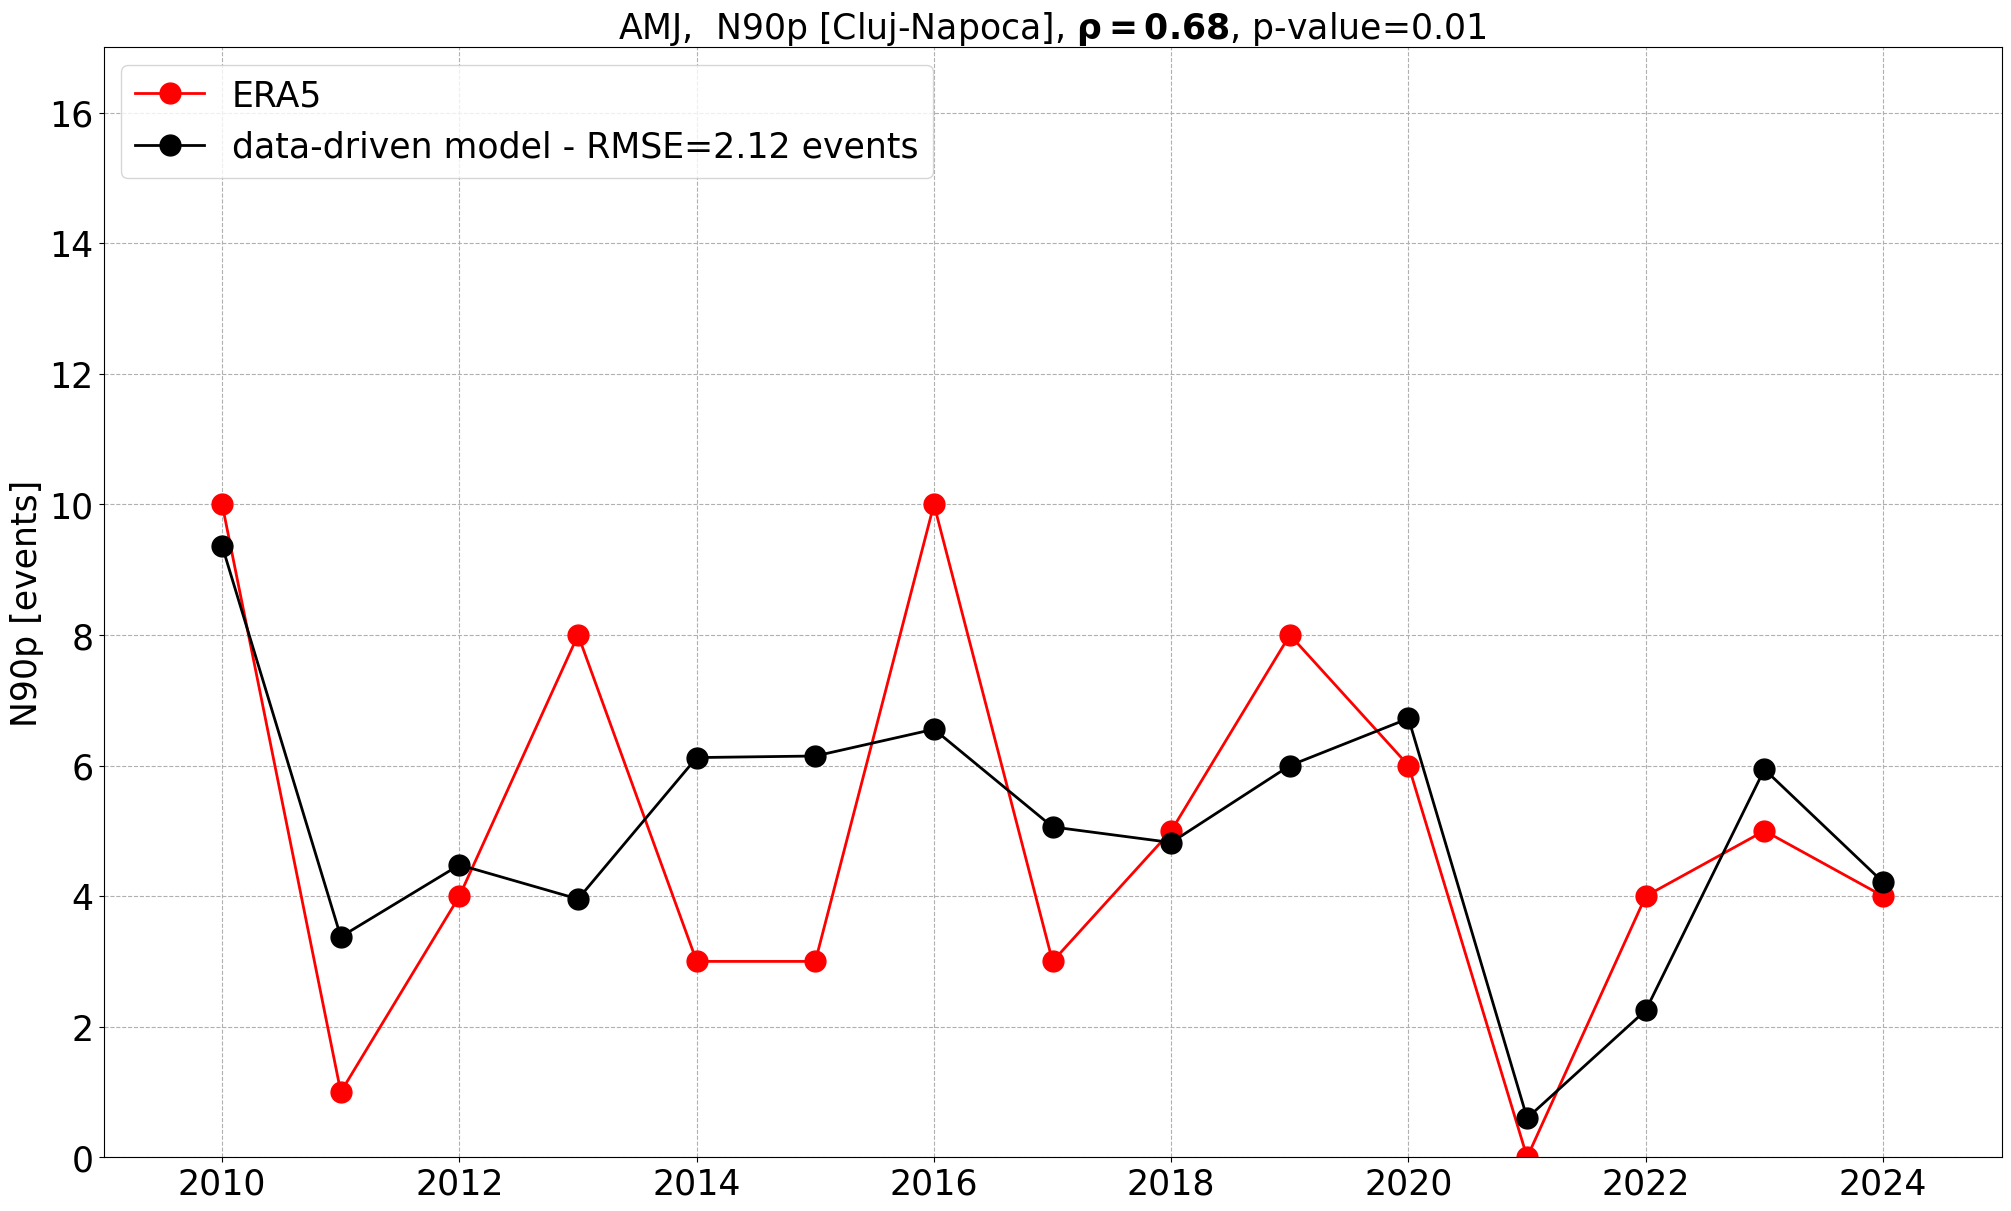

In [12]:
# plot

fig, ax = plt.subplots(figsize=(20, 12), constrained_layout=True)

init = 2
time_step = 5


rmse_forecast = np.sqrt(mean_squared_error(Y_test[init::time_step],Y_pred[init::time_step]))


ax.plot(
    pd.to_datetime(Y_test.index[init::time_step]).year,
    Y_test[init::time_step],
    c='red',marker='o', ms = 15, label=f'ERA5',
    #label=f'Target ({dataset_NQp})',
    linewidth=2)

ax.plot(
    pd.to_datetime(Y_test.index[init::time_step]).year,
    Y_pred[init::time_step],
    color = 'k', marker='o', ms=15,
    # color='tab:green',
    label='{} - RMSE={:.2f} events'.format('data-driven model', rmse_forecast),
    # linestyle='go-',
    linewidth=2
)

corr=sp.pearsonr(Y_test[init::time_step],Y_pred[init::time_step])


ax.legend(loc='upper left', fontsize=25)
ax.set_xlabel('', fontsize=25)
ax.set_ylabel('N{}p [events]'.format(int(quantile*100)), fontsize=25)
ax.set_ylim(0,17)
ax.set_xlim(2009,2025)
ax.tick_params(axis='y', labelsize=25) 
ax.tick_params(axis='x', labelsize=25) 
ax.set_title('AMJ,  N{}p [{}], $\\mathbf{{\\rho = {:.2f}}}$, p-value={:.2f}'.format(int(quantile*100), region, corr.statistic, corr.pvalue), fontsize=25)
ax.grid(ls='--')
#plt.savefig(path+'figures/forecast_AMJ_{}_{}_at{}_{}{}.png'.format(region, period, accumulation_time, num_eval, sel_iter))

# Show the plot
plt.show()